Hypothesis 1: The revelation of a Data-scandal leads to an abrupt increase in privacy-related Google search activity compared to the pre-event period.

In [2]:
#imports

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

Search terms for action to scandal:


how_to_delete_Facebook

how_to_delete_Facebook_account

delete_Facebook

deactivate_Facebook 

Facebook_privacy_settings

Facebook_security_settings


In [3]:
path = [ "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/deactivate_Facebook.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook_account.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook.csv ",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_privacy_settings.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_security_settings.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/how_to_delete_Facebook.csv",]

In [4]:
def loadcsv (path, col_name):
    df = pd.read_csv (path, skiprows = 1, names = ["day", col_name], index_col= "day")

    df[col_name]= pd.to_numeric (df[col_name], errors = "coerce")
    df.index = pd.to_datetime (df.index,errors = "coerce" )

    df = df.dropna().sort_index()
    return df



In [5]:
dfdeactivate_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/deactivate_Facebook.csv","deactivate_Facebook"
)

dfdelete_Facebook_account = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook_account.csv","delete_Facebook_account"
)

dfdelete_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook.csv","delete_Facebook"
)

dfFacebook_privacy_settings = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_privacy_settings.csv","Facebook_privacy_settings"
)


dfFacebook_security_settings = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_security_settings.csv","Facebook_security_settings"
)

dfhow_to_delete_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/how_to_delete_Facebook.csv","how_to_delete_Facebook."
)

/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_4505/2949341574.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_4505/2949341574.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_4505/2949341574.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5k

In [6]:
#using the mean interest across search terms

dfmerged = pd.concat (
    [dfdeactivate_Facebook ,dfdelete_Facebook_account,dfdelete_Facebook,dfFacebook_privacy_settings,dfFacebook_security_settings,dfhow_to_delete_Facebook],
    axis = 1, join = 'inner'
)

dfmerged ["interest"]= dfmerged.mean(axis = 1)

dfmerged

,deactivate_Facebook,delete_Facebook_account,delete_Facebook,Facebook_privacy_settings,Facebook_security_settings,how_to_delete_Facebook.,interest
day,,,,,,,
2018-02-16,68.0,44.0,39.0,26.0,0.0,43.0,36.666667
2018-02-17,68.0,52.0,43.0,19.0,0.0,48.0,38.333333
2018-02-18,83.0,55.0,44.0,21.0,0.0,51.0,42.333333
2018-02-19,75.0,44.0,41.0,21.0,0.0,43.0,37.333333
2018-02-20,64.0,43.0,38.0,25.0,0.0,42.0,35.333333
...,...,...,...,...,...,...,...
2018-05-21,81.0,46.0,38.0,18.0,0.0,41.0,37.333333
2018-05-22,82.0,44.0,36.0,22.0,0.0,37.0,36.833333
2018-05-23,75.0,46.0,38.0,0.0,0.0,41.0,33.333333


In [7]:
# for 14 days before and 14 days after
scandalpublic = pd.Timestamp("2018-3-17")

pre_event14 = dfmerged.loc[scandalpublic - pd.Timedelta(days=14) : scandalpublic - pd.Timedelta(days=1)]
post_event14 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=14)]

stat, p_value = mannwhitneyu(
    post_event14["interest"],
    pre_event14["interest"],
    alternative="greater"
)

print("Analysis for 14 days before publication of scandal and 30 days after")
print("U:", stat)
print("p-value:", p_value)
print("Mean pre:", pre_event14["interest"].mean())
print("Mean post:", post_event14["interest"].mean())
print("Δ mean:", post_event14["interest"].mean() - pre_event14["interest"].mean())



n1 = len(pre_event14)
n2 = len(post_event14)

effect_size = stat / (n1 * n2)
print("Effect size ", effect_size)

Analysis for 14 days before publication of scandal and 30 days after
U: 202.0
p-value: 1.264902714662673e-05
Mean pre: 31.821428571428573
Mean post: 63.4
Δ mean: 31.578571428571426
Effect size  0.9619047619047619


In [8]:
# for 14 days before and 30 days to measure longterm
scandalpublic = pd.Timestamp("2018-3-17")

pre_event14 = dfmerged.loc[scandalpublic - pd.Timedelta(days=14) : scandalpublic - pd.Timedelta(days=1)]
post_event30 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=30)]

stat, p_value = mannwhitneyu(
    post_event30["interest"],
    pre_event14["interest"],
    alternative="greater"
)

print("Analysis for 14 days before publication of scandal and 30 days after")
print("U:", stat)
print("p-value:", p_value)
print("Mean pre:", pre_event14["interest"].mean())
print("Mean post:", post_event30["interest"].mean())
print("Δ mean:", post_event30["interest"].mean() - pre_event14["interest"].mean())



n1 = len(pre_event14)
n2 = len(post_event30)

effect_size = stat / (n1 * n2)
print("Effect size ", effect_size)

Analysis for 14 days before publication of scandal and 30 days after
U: 426.0
p-value: 1.5927697344505463e-07
Mean pre: 31.821428571428573
Mean post: 55.892473118279575
Δ mean: 24.071044546851002
Effect size  0.9815668202764977


In [9]:
# for 14 days before and 60 days to measure longterm
pre_event14 = dfmerged.loc[scandalpublic - pd.Timedelta(days=14) : scandalpublic - pd.Timedelta(days=1)]
post_event60 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=60)]

stat, p_value = mannwhitneyu(
    post_event60["interest"],
    pre_event14["interest"],
    alternative="greater"
)

print("Analysis for 14 days before publication of scandal and 60 days after")
print("U:", stat)
print("p-value:", p_value)
print("Mean pre:", pre_event14["interest"].mean())
print("Mean post:", post_event60["interest"].mean())
print("Δ mean:", post_event60["interest"].mean() - pre_event14["interest"].mean())



n1 = len(pre_event14)
n2 = len(post_event60)

effect_size = stat / (n1 * n2)
print("Effect size ", effect_size)

Analysis for 14 days before publication of scandal and 60 days after
U: 810.5
p-value: 9.532168355849979e-08
Mean pre: 31.821428571428573
Mean post: 47.13934426229508
Δ mean: 15.31791569086651
Effect size  0.9490632318501171


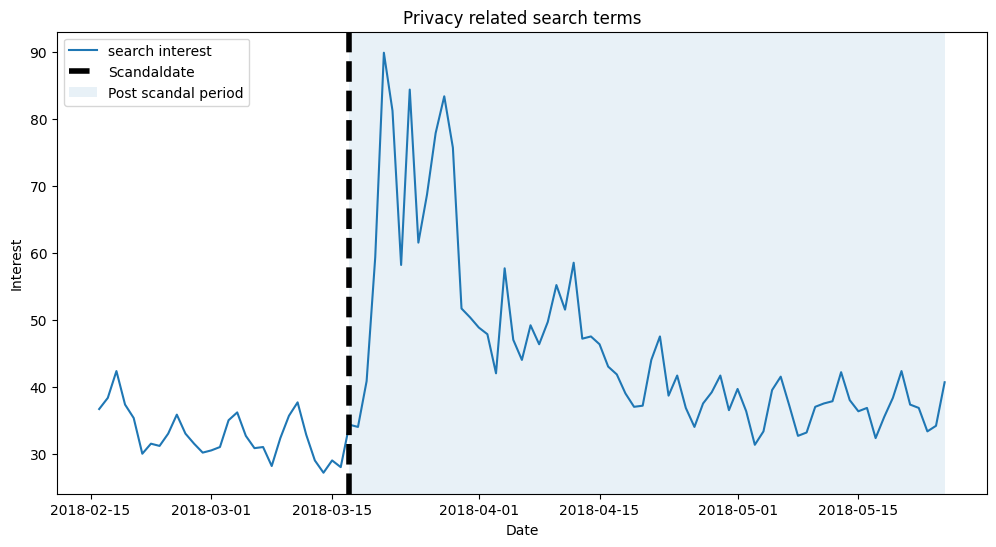

In [10]:
plt.figure(figsize = (12,6))
plt.plot(dfmerged.index, dfmerged["interest"], label = "search interest")

plt.axvline (scandalpublic, linewidth = 4, color = "black", linestyle = "--", label = "Scandaldate")

plt.axvspan (
    scandalpublic, dfmerged.index.max(),alpha=0.1, label = "Post scandal period"
)

plt.title ("Privacy related search terms")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.show()




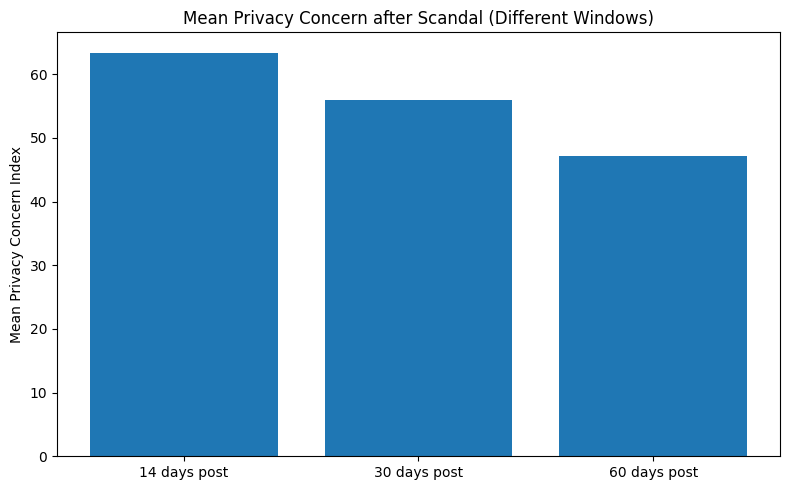

In [11]:
summary = pd.DataFrame({
    "Window": ["14 days post", "30 days post", "60 days post"],
    "Mean interest": [
        post_event14["interest"].mean(),
        post_event30["interest"].mean(),
        post_event60["interest"].mean()
    ]
})

plt.figure(figsize=(8,5))
plt.bar(summary["Window"], summary["Mean interest"])
plt.ylabel("Mean Privacy Concern Index")
plt.title("Mean Privacy Concern after Scandal (Different Windows)")
plt.tight_layout()
plt.show()


Privacy concern index --> Proactive behaviour 
Does the scandal increase privacy concern?

The analysis shows that there is a direct strong increase in searches related to privacy concern after the scandal of cambridge analytica became public. To measure the effect we used different time spans, 14 days before and after and for longterm effects 14 days and 30 & 60 days after. 

We were able to see a stark increase in the privacy concern interest immediately following the publication of the event which lowered after a period but stayed significantly higher for 2 months. 

The search intensity after 14 days had a increase of (delta + 31.58) with a very high peak and difference before and after the incident(U = 202.0, p<.001, effectsize 0.96).

This effect can be also observed looking at a longer timespan 30,60 days afterwards this increase is consistent and just decreases very gradually (delta +24.07, , +15.32).

--> Issue attention cycle 





Notizen 

- die ganzen Measurements im Paper dem Plakat erklären
- vllt. noch robustheit mit placebo testen falls zeit
